Importing packages and loading datasets

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestRegressor


In [21]:
# Formatting large numbers for visualization
def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

In [22]:
# Loading datasets
input_path = '../data/cleaned/customer_metrics_with_product_related_features.csv'
df = pd.read_csv(input_path)

In [23]:
#remove customers if Profit is outside the range of -300k & 10 million
print(df[(df["TotalProfit"] < -300000) | (df["TotalProfit"] > 3000000)])
df = df[(df["TotalProfit"] > -300000) & (df["TotalProfit"] < 3000000)]

                CustomerName  TotalRevenue   TotalProfit  TotalUnitPrice  \
125  BURKE AND SONS AND SONS    15465236.3  4.200976e+06    4.176623e+06   
734        ROBERTS LLC GROUP    17079006.7  5.131414e+06    3.877713e+05   

     TotalSalesQty  OrderCount  NumDistinctProducts  NumDistinctProductGroups  \
125       96079455       11814                 1116                        43   
734      187257427        8237                 1593                        29   

     BranchCount TopProductID  ... ProductConcentrationIndex  \
125            2  UON-721-XC7  ...                  0.011856   
734            1  TUN-499-RC6  ...                  0.002046   

     TopProductRevenueShare  TopProductGroupRevenueShare  \
125                0.042630                     0.493807   
734                0.058059                     0.185733   

     CustomerLifetimeDays  AvgOrderValue  RepeatPurchaseRatio  \
125                   724    1309.060124            10.586022   
734                   7

In [24]:
df.columns

Index(['CustomerName', 'TotalRevenue', 'TotalProfit', 'TotalUnitPrice',
       'TotalSalesQty', 'OrderCount', 'NumDistinctProducts',
       'NumDistinctProductGroups', 'BranchCount', 'TopProductID',
       'TopProductGroupID', 'ProductDiversityIndex',
       'ProductConcentrationIndex', 'TopProductRevenueShare',
       'TopProductGroupRevenueShare', 'CustomerLifetimeDays', 'AvgOrderValue',
       'RepeatPurchaseRatio', 'HighProfitProductShare', 'PopularProductShare',
       'HighProfitOrderRatio', 'PopularOrderRatio'],
      dtype='object')

Selecting features for training the model

In [25]:
# Selected features
features = [
    'TotalRevenue', 'TotalProfit', 'TotalUnitPrice', 
    'OrderCount', 'NumDistinctProducts','BranchCount', 
       'HighProfitOrderRatio','PopularOrderRatio', 
        'NumDistinctProductGroups', 
        'CustomerLifetimeDays', 
        'RepeatPurchaseRatio'
]

In [26]:
# Exclude the target feature "TotalRevenue" from feature_columns 
feature_columns_excluded = [
    'TotalProfit', 
    'TotalUnitPrice', 
    'OrderCount', 
    'NumDistinctProducts', 
    'BranchCount', 
    'HighProfitOrderRatio', 
    'PopularOrderRatio',
        'NumDistinctProductGroups', 
        'CustomerLifetimeDays', 
        'RepeatPurchaseRatio'
]

In [27]:
scaler = StandardScaler()
# scaling features to ensure bias is removed
customer_metrics_scaled = scaler.fit_transform(df[features])

Use random forest regressor to determine importance and weights of each feature

In [28]:
# Use random forest regressor to determine importance of each feature
rf = RandomForestRegressor(n_estimators=100, random_state=42) 
X = df[feature_columns_excluded]
Y = df["TotalRevenue"]
rf.fit(X, Y)
accuracy = rf.score(X, Y)

# Store and print importance of each feature
feature_importance = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=["Importance"]).sort_values("Importance", ascending=False)
print(feature_importance.sort_values("Importance", ascending=False))
print(f'\nAccuracy using Random Forest model: {accuracy:.2f}')

                          Importance
TotalProfit                 0.853572
PopularOrderRatio           0.072924
OrderCount                  0.024334
HighProfitOrderRatio        0.022493
TotalUnitPrice              0.007788
RepeatPurchaseRatio         0.005745
NumDistinctProducts         0.005676
NumDistinctProductGroups    0.003543
CustomerLifetimeDays        0.003323
BranchCount                 0.000603

Accuracy using Random Forest model: 0.98


In [29]:
# Store and print correlation of each feature with target feature TotalRevenue
correlation = X.corrwith(Y)
print(correlation)
feature_correlation = pd.DataFrame(correlation, columns=["Correlation"])

TotalProfit                 0.960275
TotalUnitPrice              0.625447
OrderCount                  0.848177
NumDistinctProducts         0.542353
BranchCount                 0.182207
HighProfitOrderRatio        0.834433
PopularOrderRatio           0.884730
NumDistinctProductGroups    0.484243
CustomerLifetimeDays        0.181807
RepeatPurchaseRatio         0.209470
dtype: float64


In [30]:
# Find feature weights from importance
feature_importance["Importance"] /= feature_importance["Importance"].sum()
feature_correlation["Correlation"] = np.abs(feature_correlation["Correlation"])
feature_correlation["Correlation"] /= feature_correlation["Correlation"].sum()

# Merge DataFrames
feature_weights = feature_importance.merge(feature_correlation, left_index=True, right_index=True)

# Combine Importance and Correlation
weight_importance = 0.6  # adjust the weight of importance as required
feature_weights["FinalWeight"] = (weight_importance * feature_weights["Importance"]) + ((1 - weight_importance) * feature_weights["Correlation"])

# Normalize Final Weights
feature_weights["FinalWeight"] /= feature_weights["FinalWeight"].sum()

# Display Results
print("\nFeature Weights Based on Importance and Correlation of selected features:")
weights = feature_weights["FinalWeight"].values
weights = np.insert(weights, 0, 1)  # insert 0 for "TotalRevenue"
print(weights)
# Apply the weights to the normalized features
weightedFeatures = customer_metrics_scaled * weights


Feature Weights Based on Importance and Correlation of selected features:
[1.         0.57890846 0.10526734 0.07357188 0.07151134 0.04815838
 0.01801071 0.04111371 0.03579412 0.01463412 0.01302993]


Find optimal number of clusters using performance metrics

Silhouette Score(0-1, 1 being ideal), Davies-Bouldin Index(0(ideal) - infinity), Calinski-Harabasz Index(High value is good)
0.8862334066521115
0.4900765904531273
4257.725277477625


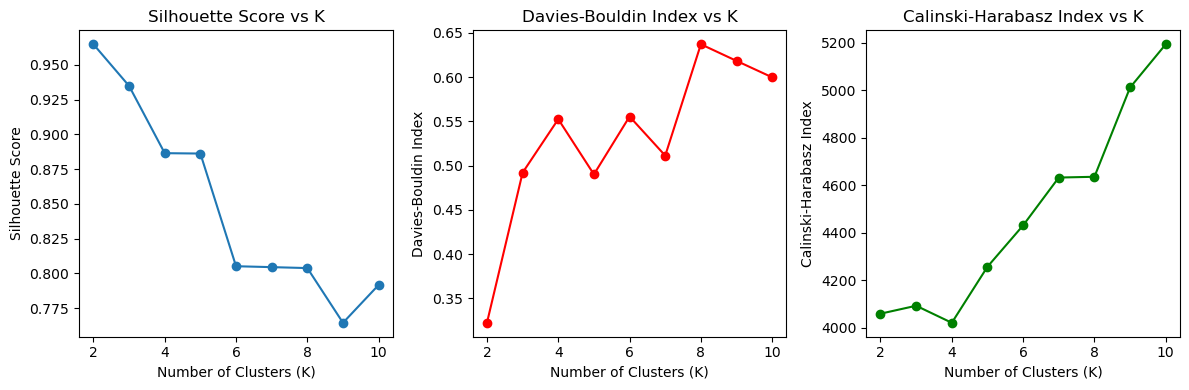

0.8862334066521115


In [31]:
# Range of K values to try
K_range = range(2, 11)

# Lists to store the scores
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

print("Silhouette Score(0-1, 1 being ideal), Davies-Bouldin Index(0(ideal) - infinity), Calinski-Harabasz Index(High value is good)")

# Run model through each number of clusters
for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(weightedFeatures)

    # Compute metrics
    silhouette_scores.append(silhouette_score(weightedFeatures, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(weightedFeatures, clusters))
    calinski_harabasz_scores.append(calinski_harabasz_score(weightedFeatures, clusters))
    if K == 5:
        print(silhouette_score(weightedFeatures, clusters))
        print(davies_bouldin_score(weightedFeatures, clusters))
        print(calinski_harabasz_score(weightedFeatures, clusters))

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')

plt.subplot(1, 3, 2)
plt.plot(K_range, davies_bouldin_scores, marker='o', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs K')

plt.subplot(1, 3, 3)
plt.plot(K_range, calinski_harabasz_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs K')

plt.tight_layout()
plt.show()
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(weightedFeatures)
print(silhouette_score(weightedFeatures, clusters))

The optimal number of clusters was found to be 5, the model is then set up using 5 clusters

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 4 0 0 0 1 0 2 2 0 0 0 0 1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 2 0 0 3 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 3 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

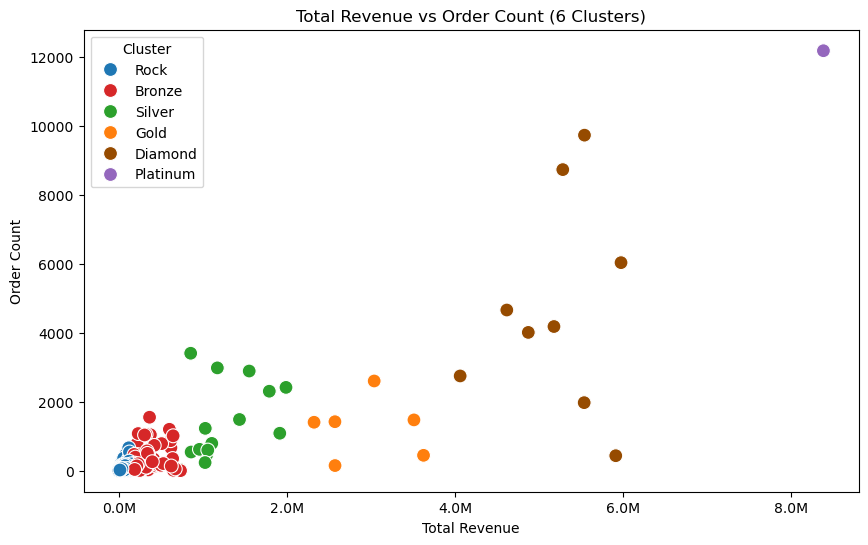

In [32]:
from matplotlib.patches import Ellipse

# Create a KMeans model with 6 clusters
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_6 = kmeans_6.fit_predict(weightedFeatures)

# We assume the first column of customer_metrics_scaled represents revenue.
# Compute a weighted average revenue for each cluster using the membership degrees.
avg_revenue = []
for i in range(6):
    # Select the revenue values from customer_metrics_scaled (column 0)
    revenue = customer_metrics_scaled[clusters_6 == i, 0]
    # Compute the average revenue for cluster i
    if len(revenue) > 0:
        cluster_avg = np.mean(revenue)
    else:
        cluster_avg = 0
    avg_revenue.append(cluster_avg)
avg_revenue = np.array(avg_revenue)

# Sort clusters by average revenue so that the lowest revenue cluster gets label 0,
# and the highest gets label (num_clusters-1)
order = np.argsort(avg_revenue)
mapping = np.empty_like(order)
mapping[order] = np.arange(6)

# Apply the mapping to convert original memberships to the new ordered labels
renumbered_labels = mapping[clusters_6]

print(renumbered_labels)
# Add the ClusterLabel column to the features list
cluster_names = {0: 'Rock', 1: 'Bronze', 2: 'Silver', 3: 'Gold', 4: 'Diamond', 5: 'Platinum'}
renumbered_labels = np.vectorize(cluster_names.get)(renumbered_labels)
df.loc[:, 'ClusterLabel'] = renumbered_labels

# Define the custom palette in the same order as the cluster names
custom_palette = {
    'Rock': "#1f77b4",  # Blue
    'Bronze': "#d62728",  # Red
    'Silver': "#2ca02c",  # Green
    'Gold': "#ff7f0e",  # Orange
    'Diamond': "#964b00",  # Purple
    'Platinum': "#9467bd",  # Purple
}

# Set the palette
sns.set_palette(custom_palette.values())

# Plot the graph between Total Revenue and Total Profit for the clustering
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=df, x='TotalRevenue', y='OrderCount', hue='ClusterLabel', palette=custom_palette, s=100)
plt.title('Total Revenue vs Order Count (6 Clusters)')
plt.xlabel('Total Revenue')
plt.ylabel('Order Count')

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance + np.eye(2) * 1e-2)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    ellipse = Ellipse(xy=position, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Draw ellipses around each cluster
"""
for i in range(5):
    cluster_data = df[df['ClusterLabel'] == cluster_names[i]]
    if len(cluster_data) > 0:
        position = cluster_data[['TotalRevenue', 'OrderCount']].mean(axis=0)
        covariance = np.cov(cluster_data[['TotalRevenue', 'OrderCount']].T)
        draw_ellipse(position, covariance, alpha=0.2, edgecolor=custom_palette[cluster_names[i]], fc='None', lw=2)
"""
# Create a custom legend to ensure the order of legend items
handles, labels = scatter.get_legend_handles_labels()
order = [labels.index(cluster_names[i]) for i in range(6)]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title='Cluster')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

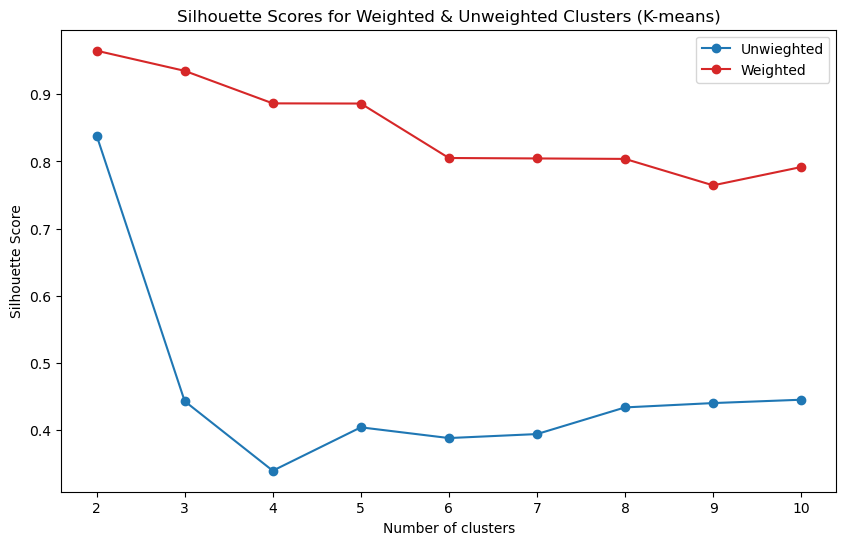

In [33]:
# Define the range for the number of clusters
cluster_range = range(2, 11)

# Initialize lists to store silhouette scores
silhouette_scores_scaled = []
silhouette_scores_weighted = []

# Compute silhouette scores for customer_metrics_scaled
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(customer_metrics_scaled)
    silhouette_scores_scaled.append(silhouette_score(customer_metrics_scaled, clusters))

# Compute silhouette scores for weightedFeatures
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(weightedFeatures)
    silhouette_scores_weighted.append(silhouette_score(weightedFeatures, clusters))

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores_scaled, marker='o', label='Unwieghted')
plt.plot(cluster_range, silhouette_scores_weighted, marker='o', label='Weighted')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Weighted & Unweighted Clusters (K-means)')
plt.legend()
plt.show()